# RQ1 — Pre-training Quality Analysis

This notebook inspects one run produced by `run_pretraining_quality.py`.

The main quantities are $\epsilon_S(t) = \frac{\|S(W_t)-S^\star\|_F^2}{\|S^\star\|_F^2}$ and the held-out pre-training generalization error $\epsilon_{\mathrm{pre}}(t).$

We inspect them against:
- raw SGD update count `step`;
- \(t/d\);
- \(t/d^2\).

The goal is to decide whether the current pre-training trajectory has converged enough and which saved checkpoints represent meaningfully different levels of pre-training quality before moving on to Task 1.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## Phase 1: pre-training

Loaded runs:
d=100  | max step =    400,000 | q = 1.753251e+02 | Q = 1.617636e+02 | Q* = 1.938272e+02 | eps_S = 2.548949e-02 | eps_pre = 7.085402e-03 | max check error = 1.048e-15
d=200  | max step =  1,600,000 | q = 3.592574e+02 | Q = 3.296115e+02 | Q* = 3.998930e+02 | eps_S = 2.748147e-02 | eps_pre = 7.502077e-03 | max check error = 1.180e-15
d=500  | max step = 10,000,000 | q = 9.068323e+02 | Q = 8.339113e+02 | Q* = 1.006328e+03 | eps_S = 2.640734e-02 | eps_pre = 7.141501e-03 | max check error = 8.119e-16


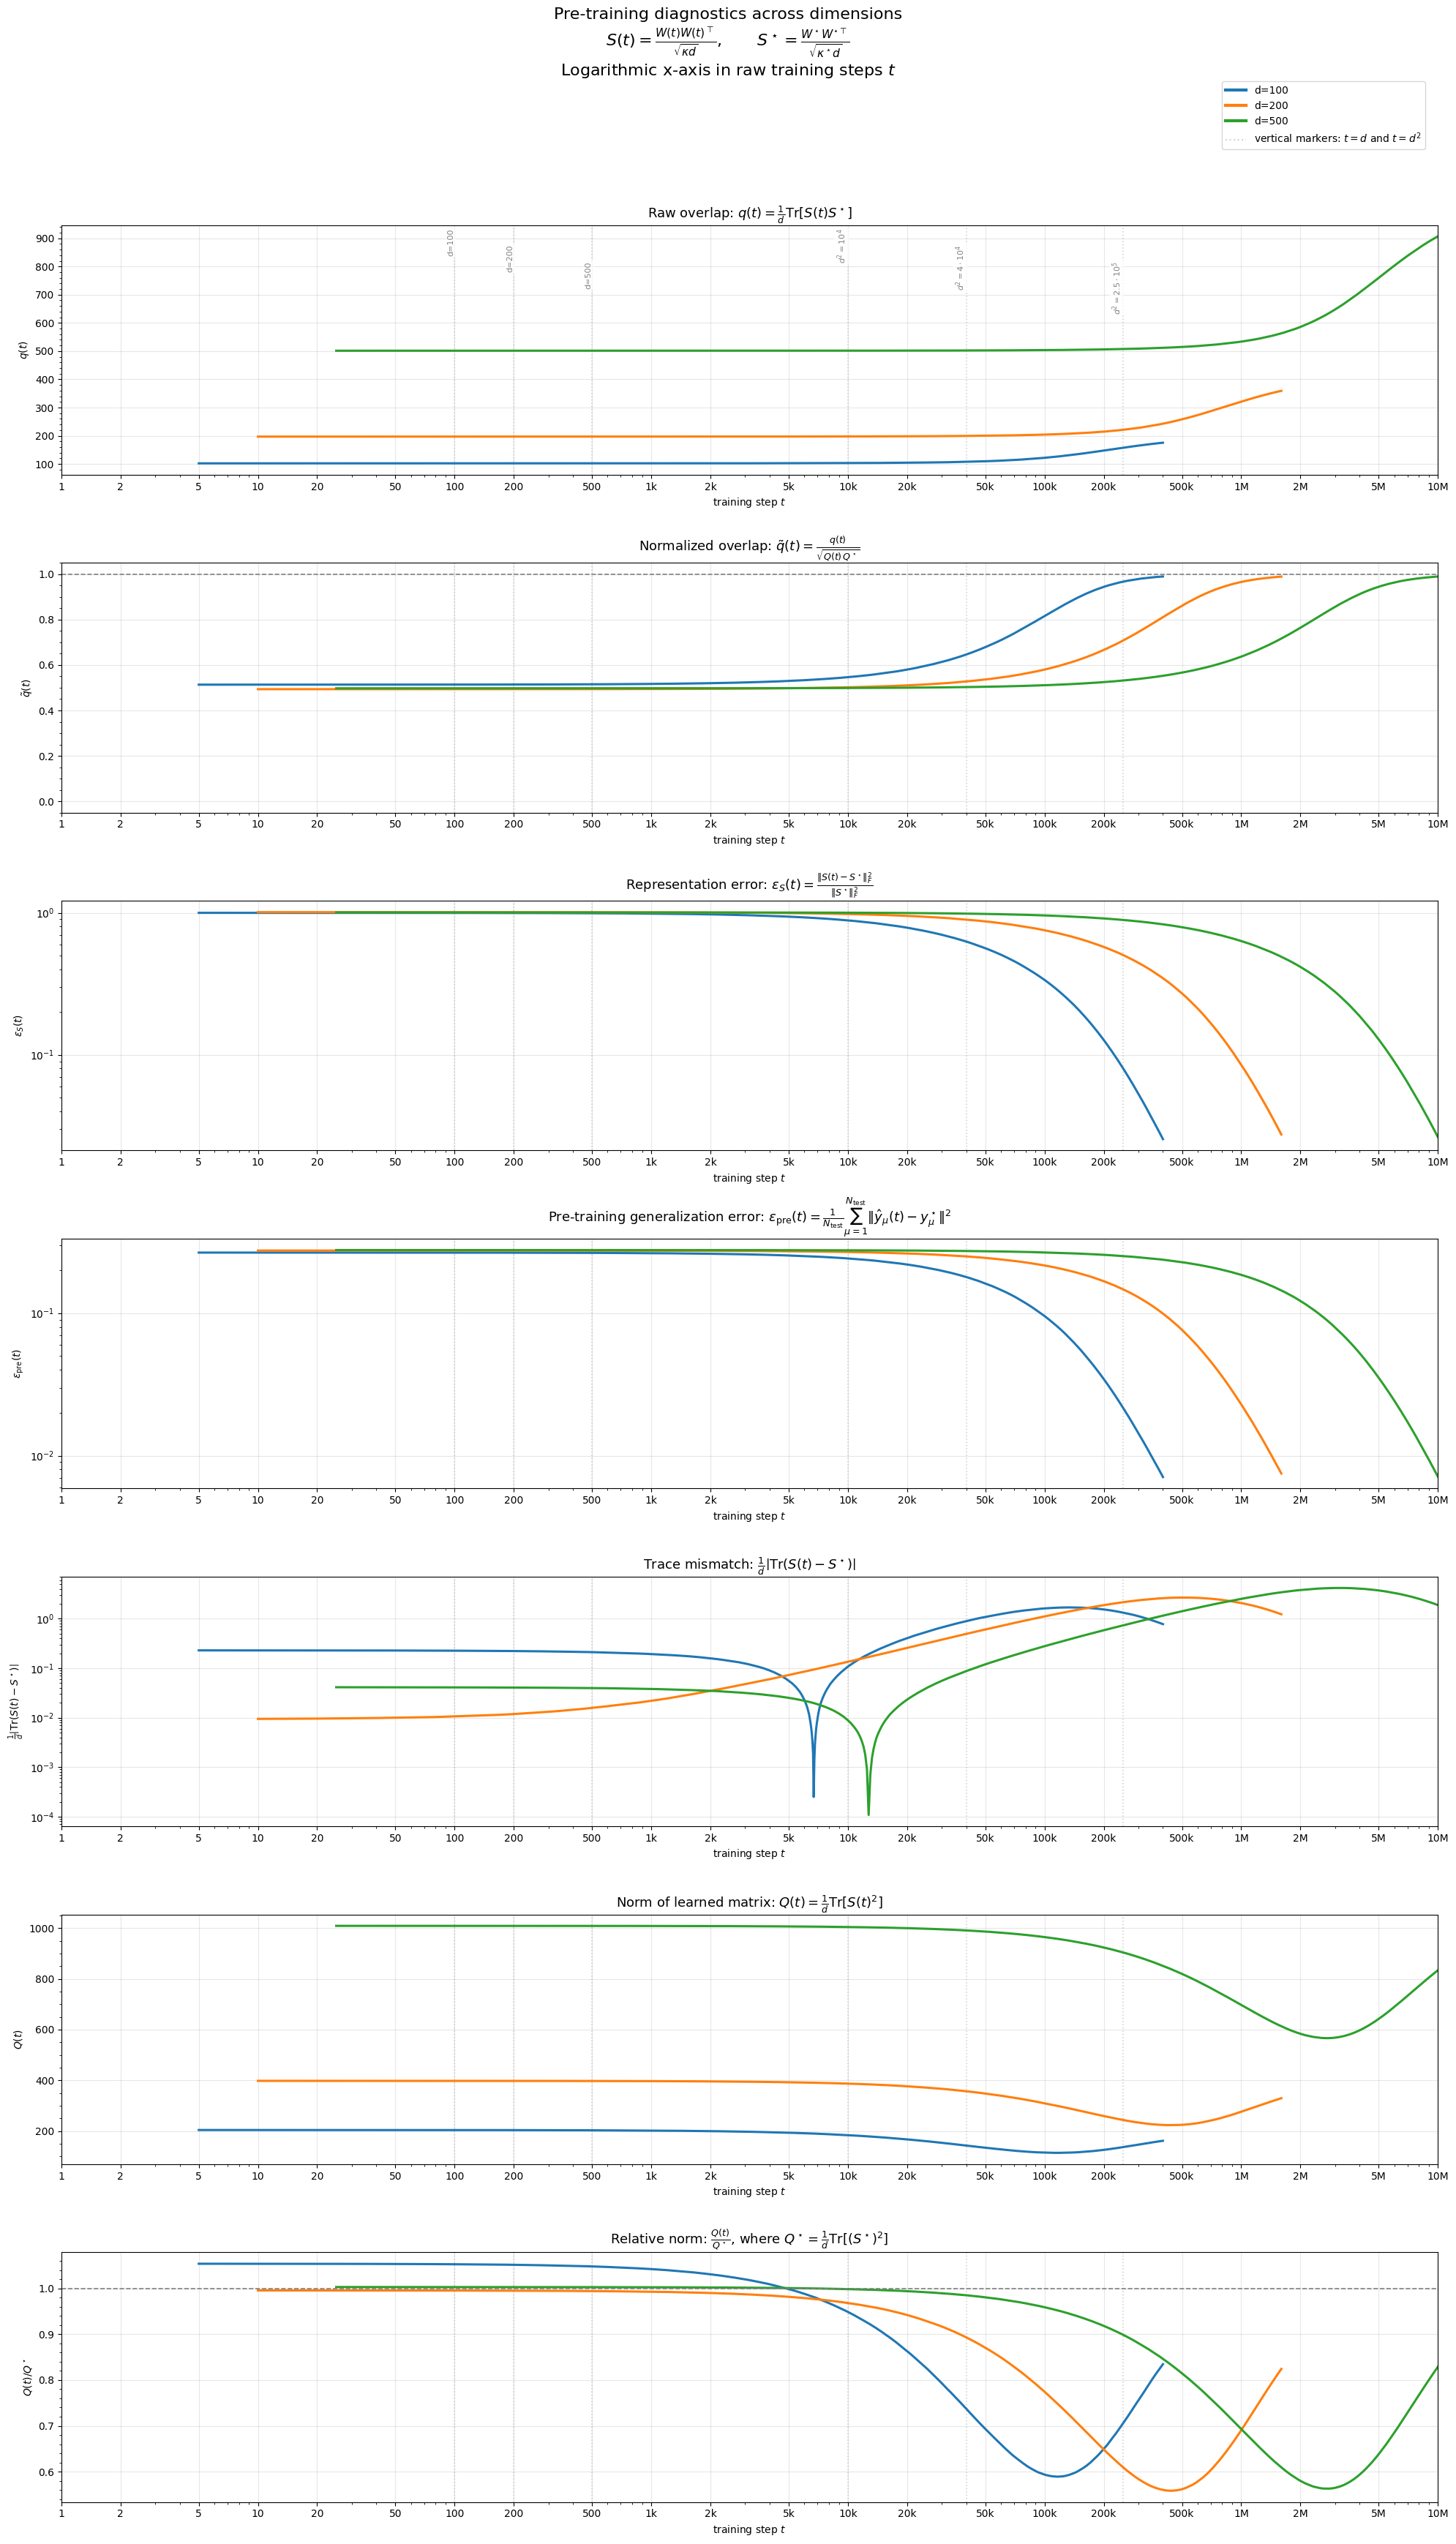

In [7]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RUNS = {
    "d=100": {"name": "scaling_d100_T5", "d": 100},
    "d=200": {"name": "scaling_d200_T5", "d": 200},
    "d=500": {"name": "scaling_d500_T5", "d": 500},
}

REQUIRED_COLUMNS = [
    "step",
    "representation_error",
    "generalization_error",
    "q",
    "Q",
    "Q_star",
    "normalized_overlap",
    "trace_mismatch",
]

FIGSIZE = (20, 35)
LINEWIDTH = 2.2
XMIN = 1


# ------------------------------------------------------------
# Locate results root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = REPO_ROOT / "results" / "quality_pretraining"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def positive_only(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    y[y <= 0] = np.nan
    return y


def format_power_label(n):
    """
    Compact formatting for d^2 labels.
    """
    if n == 10_000:
        return r"$10^4$"
    if n == 40_000:
        return r"$4\cdot 10^4$"
    if n == 250_000:
        return r"$2.5\cdot 10^5$"
    if n >= 1_000_000:
        return f"${n/1_000_000:g}\\cdot 10^6$"
    if n >= 1_000:
        k = n / 1_000
        if float(k).is_integer():
            return rf"${int(k)}\cdot 10^3$"
        return rf"${k:g}\cdot 10^3$"
    return str(n)


def add_vertical_scale_lines(ax, d_values):
    """
    Add light gray dotted vertical lines at t=d and t=d^2
    for every run.
    """
    for d in sorted(d_values):
        ax.axvline(
            d,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )
        ax.axvline(
            d**2,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )


def annotate_vertical_scale_lines(ax, d_values):
    """
    Annotate the vertical scale lines on the top panel only.
    Uses x in data coordinates and y in axes-fraction coordinates.
    """
    d_values = sorted(d_values)

    # Slight staggering to avoid overlap
    y_positions_d = [0.985, 0.92, 0.855]
    y_positions_d2 = [0.985, 0.92, 0.855]

    for i, d in enumerate(d_values):
        ax.text(
            d,
            y_positions_d[i % len(y_positions_d)],
            f"d={d}",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )

    for i, d in enumerate(d_values):
        d2 = d**2
        ax.text(
            d2,
            y_positions_d2[i % len(y_positions_d2)],
            rf"$d^2=${format_power_label(d2)}",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )


def set_log_x_ticks(ax, xmax):
    candidate_ticks = [
        1, 2, 5,
        10, 20, 50,
        100, 200, 500,
        1_000, 2_000, 5_000,
        10_000, 20_000, 50_000,
        100_000, 200_000, 500_000,
        1_000_000, 2_000_000, 5_000_000,
        10_000_000,
    ]
    ticks = [t for t in candidate_ticks if XMIN <= t <= xmax]
    ax.set_xticks(ticks)

    labels = []
    for t in ticks:
        if t >= 1_000_000:
            labels.append(f"{t/1_000_000:g}M")
        elif t >= 1_000:
            labels.append(f"{t/1_000:g}k")
        else:
            labels.append(str(int(t)))
    ax.set_xticklabels(labels)


def style_axis(ax, ylabel, title, xmax, yscale=None):
    ax.set_xscale("log")
    if yscale is not None:
        ax.set_yscale(yscale)

    ax.set_xlim(XMIN, xmax)
    set_log_x_ticks(ax, xmax)

    ax.set_xlabel(r"training step $t$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------

runs = {}
warnings_list = []

for label, info in RUNS.items():
    run_dir = RESULTS_ROOT / info["name"]
    metrics_path = run_dir / "metrics.csv"

    if not metrics_path.exists():
        warnings_list.append(f"{label}: missing file {metrics_path}")
        continue

    df = pd.read_csv(metrics_path)
    df = (
        df.sort_values("step")
          .drop_duplicates(subset="step", keep="last")
          .reset_index(drop=True)
    )

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        warnings_list.append(
            f"{label}: missing columns {missing_cols} in {metrics_path}"
        )
        continue

    d = info["d"]

    df["relative_norm"] = df["Q"] / df["Q_star"]

    df["representation_error_from_OP"] = (
        (df["Q"] + df["Q_star"] - 2.0 * df["q"]) / df["Q_star"]
    )
    df["representation_error_check_abs"] = np.abs(
        df["representation_error"] - df["representation_error_from_OP"]
    )

    # remove t=0 for log-x plotting
    df_plot = df[df["step"] > 0].copy()

    runs[label] = {
        "d": d,
        "df": df,
        "df_plot": df_plot,
        "path": metrics_path,
    }

if warnings_list:
    print("Warnings:")
    for w in warnings_list:
        print(" -", w)
    print()

if not runs:
    raise RuntimeError(
        "No valid runs were loaded. "
        "Check that the new metrics.csv files exist and contain the required columns."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Loaded runs:")
for label, payload in runs.items():
    df = payload["df"]
    d = payload["d"]
    last = df.iloc[-1]
    print(
        f"{label:6s} | "
        f"max step = {int(last['step']):>10,d} | "
        f"q = {last['q']:.6e} | "
        f"Q = {last['Q']:.6e} | "
        f"Q* = {last['Q_star']:.6e} | "
        f"eps_S = {last['representation_error']:.6e} | "
        f"eps_pre = {last['generalization_error']:.6e} | "
        f"max check error = {df['representation_error_check_abs'].max():.3e}"
    )


# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    7, 1,
    figsize=FIGSIZE,
    sharex=False,
)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {}
for i, label in enumerate(runs.keys()):
    color_map[label] = default_colors[i % len(default_colors)]

all_d_values = [payload["d"] for payload in runs.values()]
xmax = max(payload["df_plot"]["step"].max() for payload in runs.values())


# ------------------------------------------------------------
# Plot each run on each panel
# ------------------------------------------------------------

for label, payload in runs.items():
    d = payload["d"]
    df = payload["df_plot"]
    color = color_map[label]

    axes[0].plot(
        df["step"], df["q"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[1].plot(
        df["step"], df["normalized_overlap"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[2].plot(
        df["step"], positive_only(df["representation_error"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[3].plot(
        df["step"], positive_only(df["generalization_error"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[4].plot(
        df["step"], positive_only(df["trace_mismatch"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[5].plot(
        df["step"], df["Q"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[6].plot(
        df["step"], df["relative_norm"],
        lw=LINEWIDTH, color=color, label=label
    )


# ------------------------------------------------------------
# Add vertical dotted lines everywhere
# ------------------------------------------------------------

for ax in axes:
    add_vertical_scale_lines(ax, all_d_values)

# Add labels only on the top panel
annotate_vertical_scale_lines(axes[0], all_d_values)


# ------------------------------------------------------------
# Reference horizontal lines
# ------------------------------------------------------------

axes[1].axhline(
    1.0, color="gray", linestyle="--", linewidth=1.2
)

axes[6].axhline(
    1.0, color="gray", linestyle="--", linewidth=1.2
)


# ------------------------------------------------------------
# Axis styling
# ------------------------------------------------------------

style_axis(
    axes[0],
    ylabel=r"$q(t)$",
    title=(
        r"Raw overlap: "
        r"$q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)S^\star\right]$"
    ),
    xmax=xmax,
)

style_axis(
    axes[1],
    ylabel=r"$\tilde q(t)$",
    title=(
        r"Normalized overlap: "
        r"$\tilde q(t)=\frac{q(t)}{\sqrt{Q(t)\,Q^\star}}$"
    ),
    xmax=xmax,
)
axes[1].set_ylim(-0.05, 1.05)

style_axis(
    axes[2],
    ylabel=r"$\epsilon_S(t)$",
    title=(
        r"Representation error: "
        r"$\epsilon_S(t)=\frac{\|S(t)-S^\star\|_F^2}{\|S^\star\|_F^2}$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[3],
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    title=(
        r"Pre-training generalization error: "
        r"$\epsilon_{\mathrm{pre}}(t)=\frac{1}{N_{\mathrm{test}}}"
        r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
        r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[4],
    ylabel=r"$\frac{1}{d}\left|\operatorname{Tr}(S(t)-S^\star)\right|$",
    title=(
        r"Trace mismatch: "
        r"$\frac{1}{d}\left|\operatorname{Tr}(S(t)-S^\star)\right|$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[5],
    ylabel=r"$Q(t)$",
    title=(
        r"Norm of learned matrix: "
        r"$Q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)^2\right]$"
    ),
    xmax=xmax,
)

style_axis(
    axes[6],
    ylabel=r"$Q(t)/Q^\star$",
    title=(
        r"Relative norm: "
        r"$\frac{Q(t)}{Q^\star}$"
        r", where "
        r"$Q^\star=\frac{1}{d}\operatorname{Tr}\!\left[(S^\star)^2\right]$"
    ),
    xmax=xmax,
)


# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------

run_handles = [
    Line2D([0], [0], color=color_map[label], lw=3, label=label)
    for label in runs.keys()
]

scale_handles = [
    Line2D([0], [0], color="lightgray", lw=1.5, ls=":", label=r"vertical markers: $t=d$ and $t=d^2$"),
]

# Put legend well above the plots, but below the main title
fig.legend(
    handles=run_handles + scale_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.965),
    ncol=1,
    frameon=True,
)


# ------------------------------------------------------------
# Global title
# ------------------------------------------------------------

fig.suptitle(
    "Pre-training diagnostics across dimensions\n"
    r"$S(t)=\frac{W(t)W(t)^\top}{\sqrt{\kappa d}},\qquad"
    r"S^\star=\frac{W^\star W^{\star\top}}{\sqrt{\kappa^\star d}}$"
    "\n"
    "Logarithmic x-axis in raw training steps "
    r"$t$",
    fontsize=16,
    y=0.992,
)

plt.tight_layout(rect=[0, 0, 1, 0.952])
plt.show()

Loaded runs:
d=100  | step=   400,000 | t/d²=40.000 | eps_S=2.548949e-02 | eps_pre=7.085402e-03 | q=1.753251e+02 | Q/Q*=0.834576
d=200  | step= 1,600,000 | t/d²=40.000 | eps_S=2.748147e-02 | eps_pre=7.502077e-03 | q=3.592574e+02 | Q/Q*=0.824249
d=500  | step=10,000,000 | t/d²=40.000 | eps_S=2.640734e-02 | eps_pre=7.141501e-03 | q=9.068323e+02 | Q/Q*=0.828668


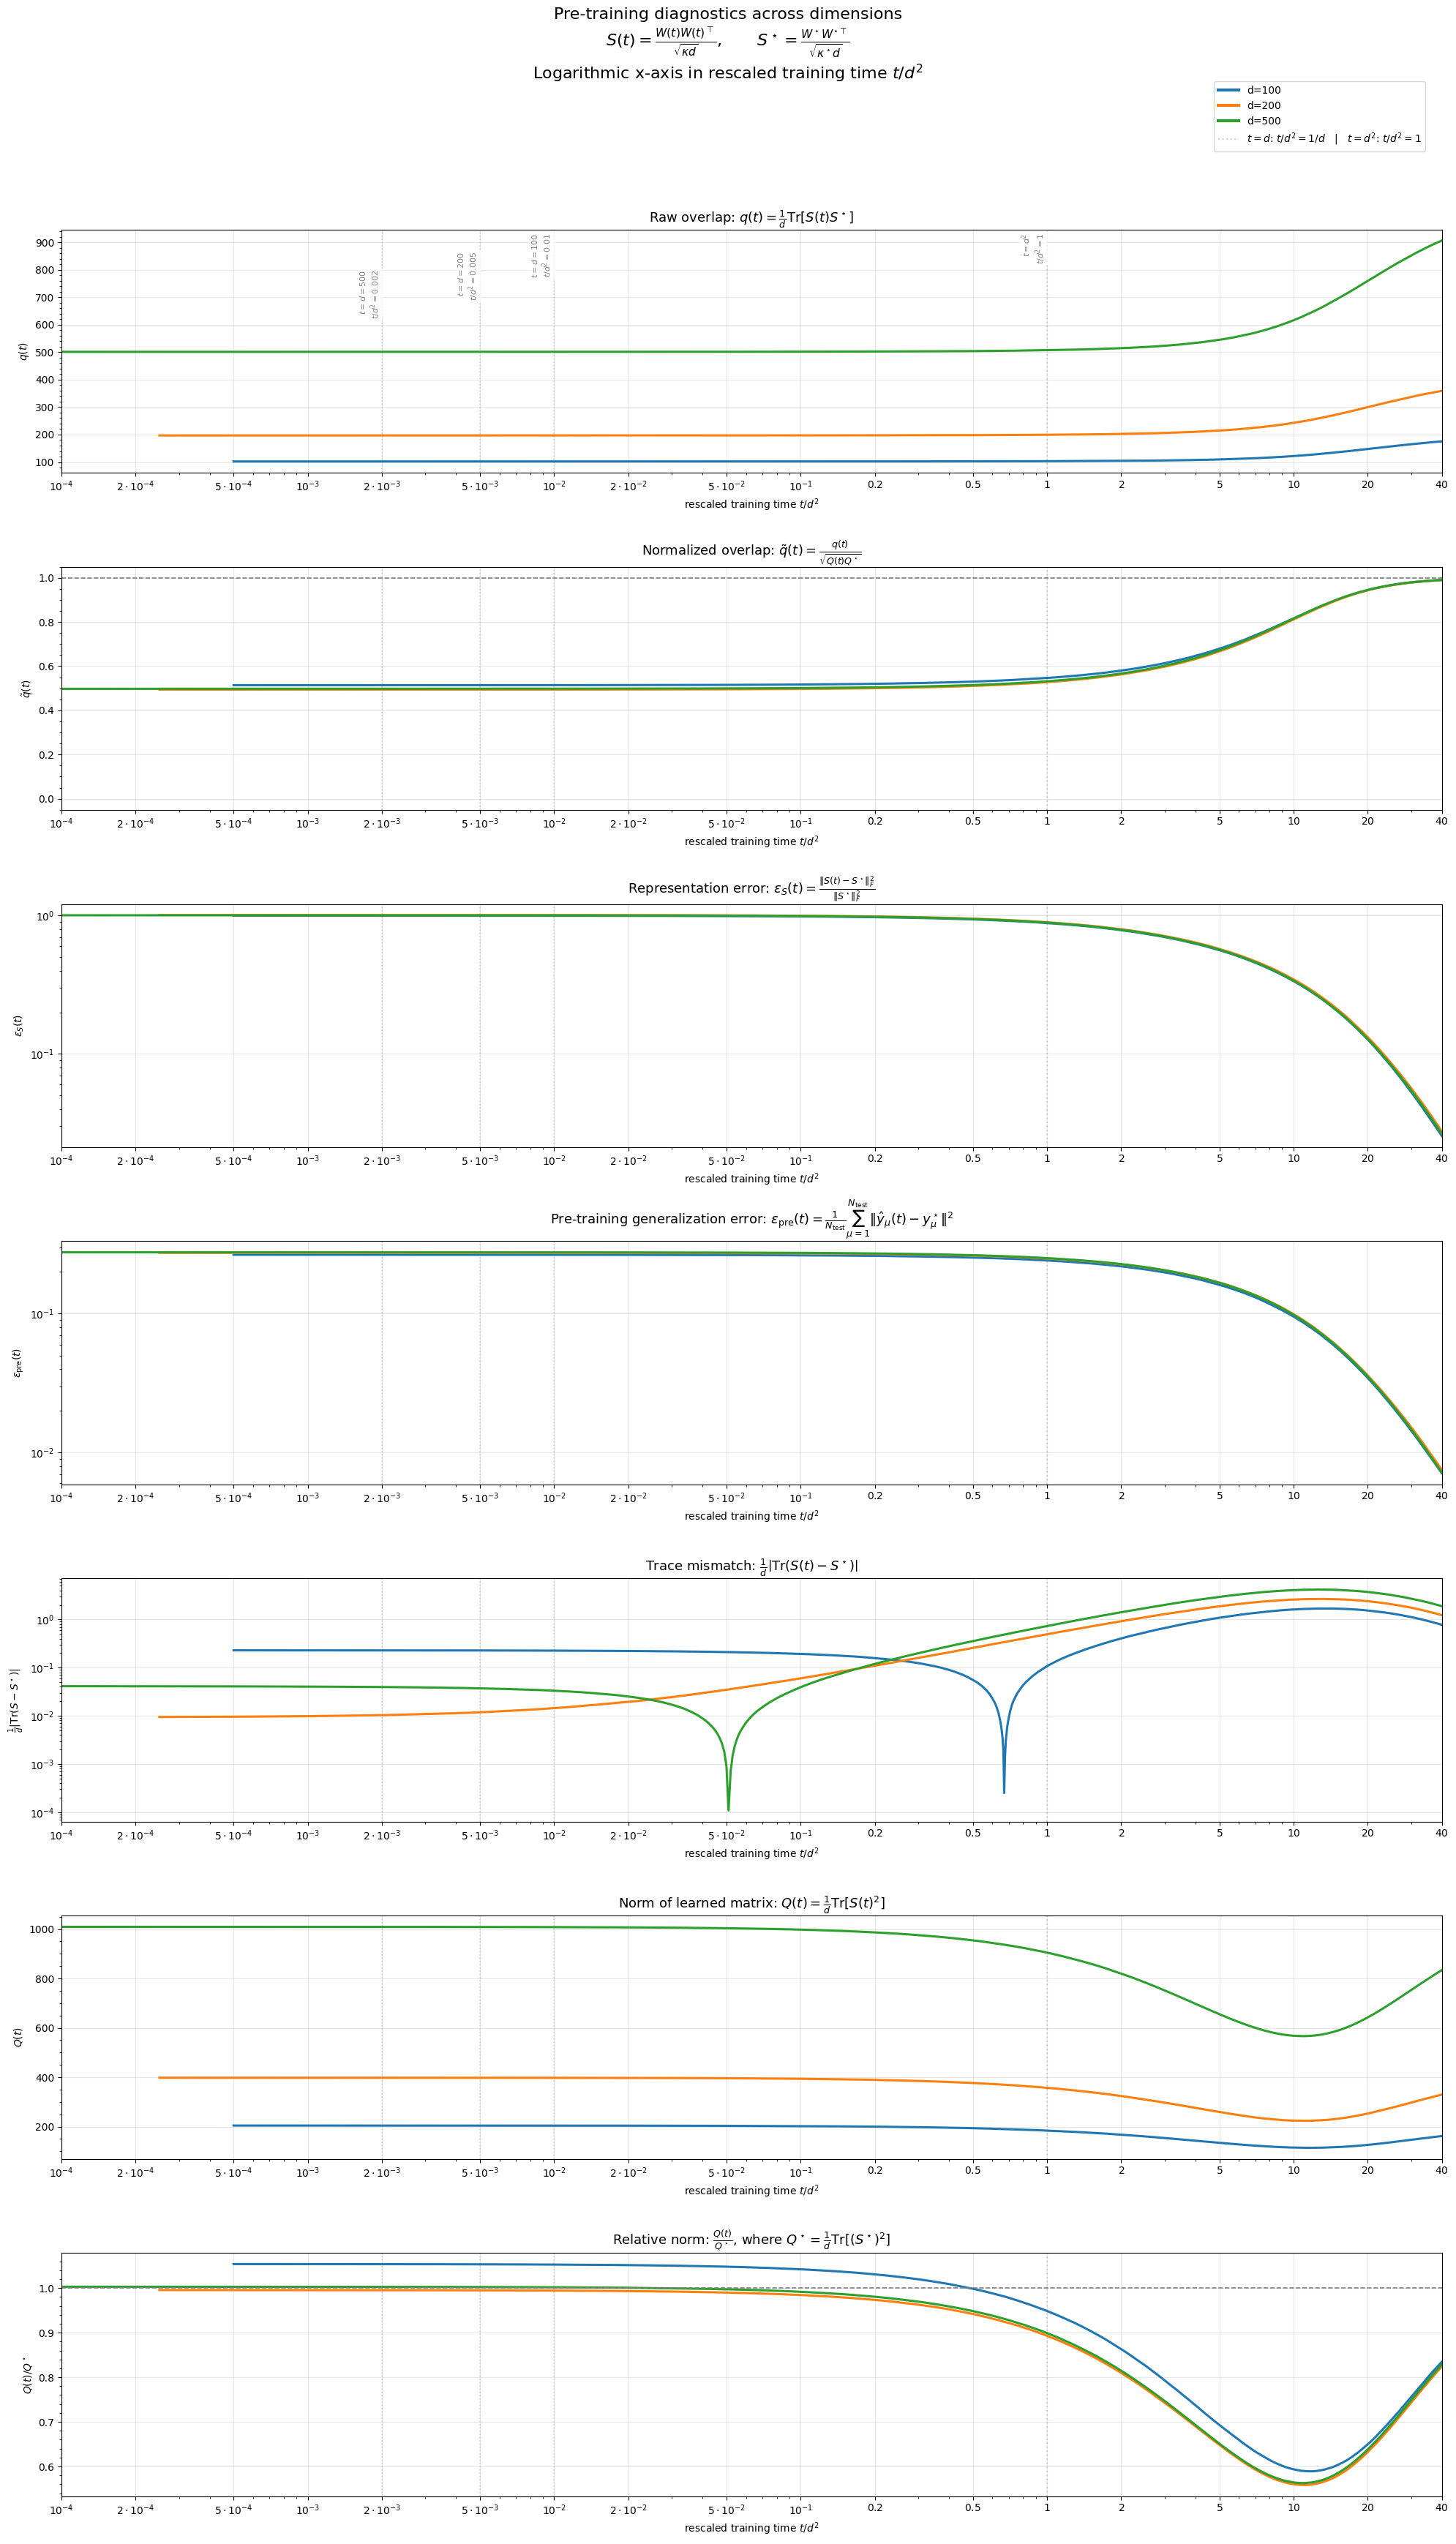

In [8]:
RUNS = {
    "d=100": {"name": "scaling_d100_T5", "d": 100},
    "d=200": {"name": "scaling_d200_T5", "d": 200},
    "d=500": {"name": "scaling_d500_T5", "d": 500},
}

REQUIRED_COLUMNS = [
    "step",
    "representation_error",
    "generalization_error",
    "q",
    "Q",
    "Q_star",
    "normalized_overlap",
    "trace_mismatch",
]

FIGSIZE = (20, 35)
LINEWIDTH = 2.2

# Full alpha range
XMIN = 1e-4
XMAX = 40.0


# ------------------------------------------------------------
# Locate results root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = REPO_ROOT / "results" / "quality_pretraining"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def positive_only(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    y[y <= 0] = np.nan
    return y


def add_vertical_scale_lines_alpha(ax, d_values):
    """
    On alpha = t/d^2 scale:
        t=d   -> alpha=1/d
        t=d^2 -> alpha=1
    """

    for d in sorted(d_values):
        ax.axvline(
            1.0 / d,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )

    # t=d^2 is alpha=1 for every d
    ax.axvline(
        1.0,
        color="lightgray",
        linestyle=":",
        linewidth=1.5,
        zorder=0,
    )


def annotate_vertical_scale_lines_alpha(ax, d_values):
    """
    Label the t=d positions and common t=d^2 position
    on the top panel only.
    """

    d_values = sorted(d_values)

    # Label alpha = 1/d
    y_positions = [0.985, 0.91, 0.835]

    for i, d in enumerate(d_values):
        alpha_d = 1.0 / d

        ax.text(
            alpha_d,
            y_positions[i],
            rf"$t=d={d}$" + "\n" + rf"$t/d^2={alpha_d:g}$",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )

    # Common d^2 location
    ax.text(
        1.0,
        0.985,
        r"$t=d^2$" + "\n" + r"$t/d^2=1$",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        color="gray",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
    )


def set_alpha_ticks(ax):
    ticks = [
        1e-4,
        2e-4,
        5e-4,
        1e-3,
        2e-3,
        5e-3,
        1e-2,
        2e-2,
        5e-2,
        1e-1,
        2e-1,
        5e-1,
        1,
        2,
        5,
        10,
        20,
        40,
    ]

    ticks = [x for x in ticks if XMIN <= x <= XMAX]

    ax.set_xticks(ticks)

    labels = [
        r"$10^{-4}$",
        r"$2\cdot10^{-4}$",
        r"$5\cdot10^{-4}$",
        r"$10^{-3}$",
        r"$2\cdot10^{-3}$",
        r"$5\cdot10^{-3}$",
        r"$10^{-2}$",
        r"$2\cdot10^{-2}$",
        r"$5\cdot10^{-2}$",
        r"$10^{-1}$",
        r"$0.2$",
        r"$0.5$",
        r"$1$",
        r"$2$",
        r"$5$",
        r"$10$",
        r"$20$",
        r"$40$",
    ]

    ax.set_xticklabels(labels)


def style_axis(
    ax,
    ylabel,
    title,
    yscale=None,
):
    ax.set_xscale("log")

    if yscale is not None:
        ax.set_yscale(yscale)

    ax.set_xlim(XMIN, XMAX)
    set_alpha_ticks(ax)

    ax.set_xlabel(r"rescaled training time $t/d^2$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13)

    ax.grid(True, alpha=0.3)
    ax.minorticks_on()


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------

runs = {}
warnings_list = []

for label, info in RUNS.items():
    run_dir = RESULTS_ROOT / info["name"]
    metrics_path = run_dir / "metrics.csv"

    if not metrics_path.exists():
        warnings_list.append(
            f"{label}: missing file {metrics_path}"
        )
        continue

    df = pd.read_csv(metrics_path)

    df = (
        df.sort_values("step")
          .drop_duplicates(
              subset="step",
              keep="last",
          )
          .reset_index(drop=True)
    )

    missing_cols = [
        c for c in REQUIRED_COLUMNS
        if c not in df.columns
    ]

    if missing_cols:
        warnings_list.append(
            f"{label}: missing columns {missing_cols}"
        )
        continue

    d = info["d"]

    # --------------------------------------------------------
    # Derived quantities
    # --------------------------------------------------------

    df["step_over_d2"] = (
        df["step"] / (d ** 2)
    )

    df["relative_norm"] = (
        df["Q"] / df["Q_star"]
    )

    # Sanity check
    df["representation_error_from_OP"] = (
        (
            df["Q"]
            + df["Q_star"]
            - 2.0 * df["q"]
        )
        / df["Q_star"]
    )

    df["representation_error_check_abs"] = (
        np.abs(
            df["representation_error"]
            - df["representation_error_from_OP"]
        )
    )

    # Exclude t=0 because x-axis is logarithmic
    df_plot = (
        df[df["step_over_d2"] > 0]
        .copy()
    )

    runs[label] = {
        "d": d,
        "df": df,
        "df_plot": df_plot,
    }


if warnings_list:
    print("Warnings:")
    for w in warnings_list:
        print(" -", w)
    print()

if not runs:
    raise RuntimeError(
        "No valid runs were loaded."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Loaded runs:")

for label, payload in runs.items():
    df = payload["df"]
    d = payload["d"]
    last = df.iloc[-1]

    print(
        f"{label:6s} | "
        f"step={int(last['step']):>10,d} | "
        f"t/d²={last['step_over_d2']:.3f} | "
        f"eps_S={last['representation_error']:.6e} | "
        f"eps_pre={last['generalization_error']:.6e} | "
        f"q={last['q']:.6e} | "
        f"Q/Q*={last['relative_norm']:.6f}"
    )


# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    7,
    1,
    figsize=FIGSIZE,
    sharex=False,
)

default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

color_map = {}

for i, label in enumerate(runs.keys()):
    color_map[label] = (
        default_colors[
            i % len(default_colors)
        ]
    )

all_d_values = [
    payload["d"]
    for payload in runs.values()
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for label, payload in runs.items():

    df = payload["df_plot"]
    color = color_map[label]

    x = df["step_over_d2"]

    # 1. Raw overlap
    axes[0].plot(
        x,
        df["q"],
        lw=LINEWIDTH,
        color=color,
        label=label,
    )

    # 2. Normalized overlap
    axes[1].plot(
        x,
        df["normalized_overlap"],
        lw=LINEWIDTH,
        color=color,
    )

    # 3. Representation error
    axes[2].plot(
        x,
        positive_only(
            df["representation_error"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 4. Generalization error
    axes[3].plot(
        x,
        positive_only(
            df["generalization_error"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 5. Trace mismatch
    axes[4].plot(
        x,
        positive_only(
            df["trace_mismatch"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 6. Raw Q
    axes[5].plot(
        x,
        df["Q"],
        lw=LINEWIDTH,
        color=color,
    )

    # 7. Relative Q
    axes[6].plot(
        x,
        df["relative_norm"],
        lw=LINEWIDTH,
        color=color,
    )


# ------------------------------------------------------------
# Vertical reference lines
# ------------------------------------------------------------

for ax in axes:
    add_vertical_scale_lines_alpha(
        ax,
        all_d_values,
    )

annotate_vertical_scale_lines_alpha(
    axes[0],
    all_d_values,
)


# ------------------------------------------------------------
# Horizontal reference lines
# ------------------------------------------------------------

axes[1].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[6].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

style_axis(
    axes[0],
    ylabel=r"$q(t)$",
    title=(
        r"Raw overlap: "
        r"$q(t)=\frac{1}{d}"
        r"\operatorname{Tr}[S(t)S^\star]$"
    ),
)

style_axis(
    axes[1],
    ylabel=r"$\tilde q(t)$",
    title=(
        r"Normalized overlap: "
        r"$\tilde q(t)="
        r"\frac{q(t)}{\sqrt{Q(t)Q^\star}}$"
    ),
)

axes[1].set_ylim(
    -0.05,
    1.05,
)

style_axis(
    axes[2],
    ylabel=r"$\epsilon_S(t)$",
    title=(
        r"Representation error: "
        r"$\epsilon_S(t)="
        r"\frac{\|S(t)-S^\star\|_F^2}"
        r"{\|S^\star\|_F^2}$"
    ),
    yscale="log",
)

style_axis(
    axes[3],
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    title=(
        r"Pre-training generalization error: "
        r"$\epsilon_{\mathrm{pre}}(t)="
        r"\frac{1}{N_{\mathrm{test}}}"
        r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
        r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    ),
    yscale="log",
)

style_axis(
    axes[4],
    ylabel=(
        r"$\frac{1}{d}"
        r"|\operatorname{Tr}(S-S^\star)|$"
    ),
    title=(
        r"Trace mismatch: "
        r"$\frac{1}{d}"
        r"\left|\operatorname{Tr}"
        r"(S(t)-S^\star)\right|$"
    ),
    yscale="log",
)

style_axis(
    axes[5],
    ylabel=r"$Q(t)$",
    title=(
        r"Norm of learned matrix: "
        r"$Q(t)=\frac{1}{d}"
        r"\operatorname{Tr}[S(t)^2]$"
    ),
)

style_axis(
    axes[6],
    ylabel=r"$Q(t)/Q^\star$",
    title=(
        r"Relative norm: "
        r"$\frac{Q(t)}{Q^\star}$"
        r", where "
        r"$Q^\star=\frac{1}{d}"
        r"\operatorname{Tr}[(S^\star)^2]$"
    ),
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

run_handles = [
    Line2D(
        [0],
        [0],
        color=color_map[label],
        lw=3,
        label=label,
    )
    for label in runs.keys()
]

scale_handles = [
    Line2D(
        [0],
        [0],
        color="lightgray",
        lw=1.5,
        ls=":",
        label=(
            r"$t=d$: $t/d^2=1/d$"
            r"   |   "
            r"$t=d^2$: $t/d^2=1$"
        ),
    ),
]

fig.legend(
    handles=run_handles + scale_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.965),
    ncol=1,
    frameon=True,
)


# ------------------------------------------------------------
# Global title
# ------------------------------------------------------------

fig.suptitle(
    "Pre-training diagnostics across dimensions\n"
    r"$S(t)=\frac{W(t)W(t)^\top}{\sqrt{\kappa d}},"
    r"\qquad"
    r"S^\star="
    r"\frac{W^\star W^{\star\top}}"
    r"{\sqrt{\kappa^\star d}}$"
    "\n"
    r"Logarithmic x-axis in rescaled training time $t/d^2$",
    fontsize=16,
    y=0.992,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.952]
)

plt.show()

## Phase 2: fine-tuning on task 1

Loaded 15 / 15 runs.

alpha= 0, d=100 | step=100,000 | t/d=1000.000 | task1=2.444361e-01 | m1²=0.983081 | ||w||²/d=1.299126 | eps_adapter=6.559126e-02 | Fpre1=3.058582e-02
alpha= 0, d=200 | step=200,000 | t/d=1000.000 | task1=2.515982e-01 | m1²=0.989208 | ||w||²/d=1.214753 | eps_adapter=5.717189e-02 | Fpre1=2.110841e-02
alpha= 0, d=500 | step=500,000 | t/d=1000.000 | task1=2.638362e-01 | m1²=0.992694 | ||w||²/d=1.087570 | eps_adapter=4.778786e-02 | Fpre1=6.116809e-03
alpha= 1, d=100 | step=100,000 | t/d=1000.000 | task1=2.221593e-01 | m1²=0.984002 | ||w||²/d=1.235630 | eps_adapter=4.644944e-02 | Fpre1=2.619343e-02
alpha= 1, d=200 | step=200,000 | t/d=1000.000 | task1=2.294025e-01 | m1²=0.989767 | ||w||²/d=1.151263 | eps_adapter=3.644354e-02 | Fpre1=1.727997e-02
alpha= 1, d=500 | step=500,000 | t/d=1000.000 | task1=2.404869e-01 | m1²=0.993139 | ||w||²/d=1.029228 | eps_adapter=2.779012e-02 | Fpre1=1.503270e-03
alpha= 5, d=100 | step=100,000 | t/d=1000.000 | task1=1.479132e-01 | m1²=0.988

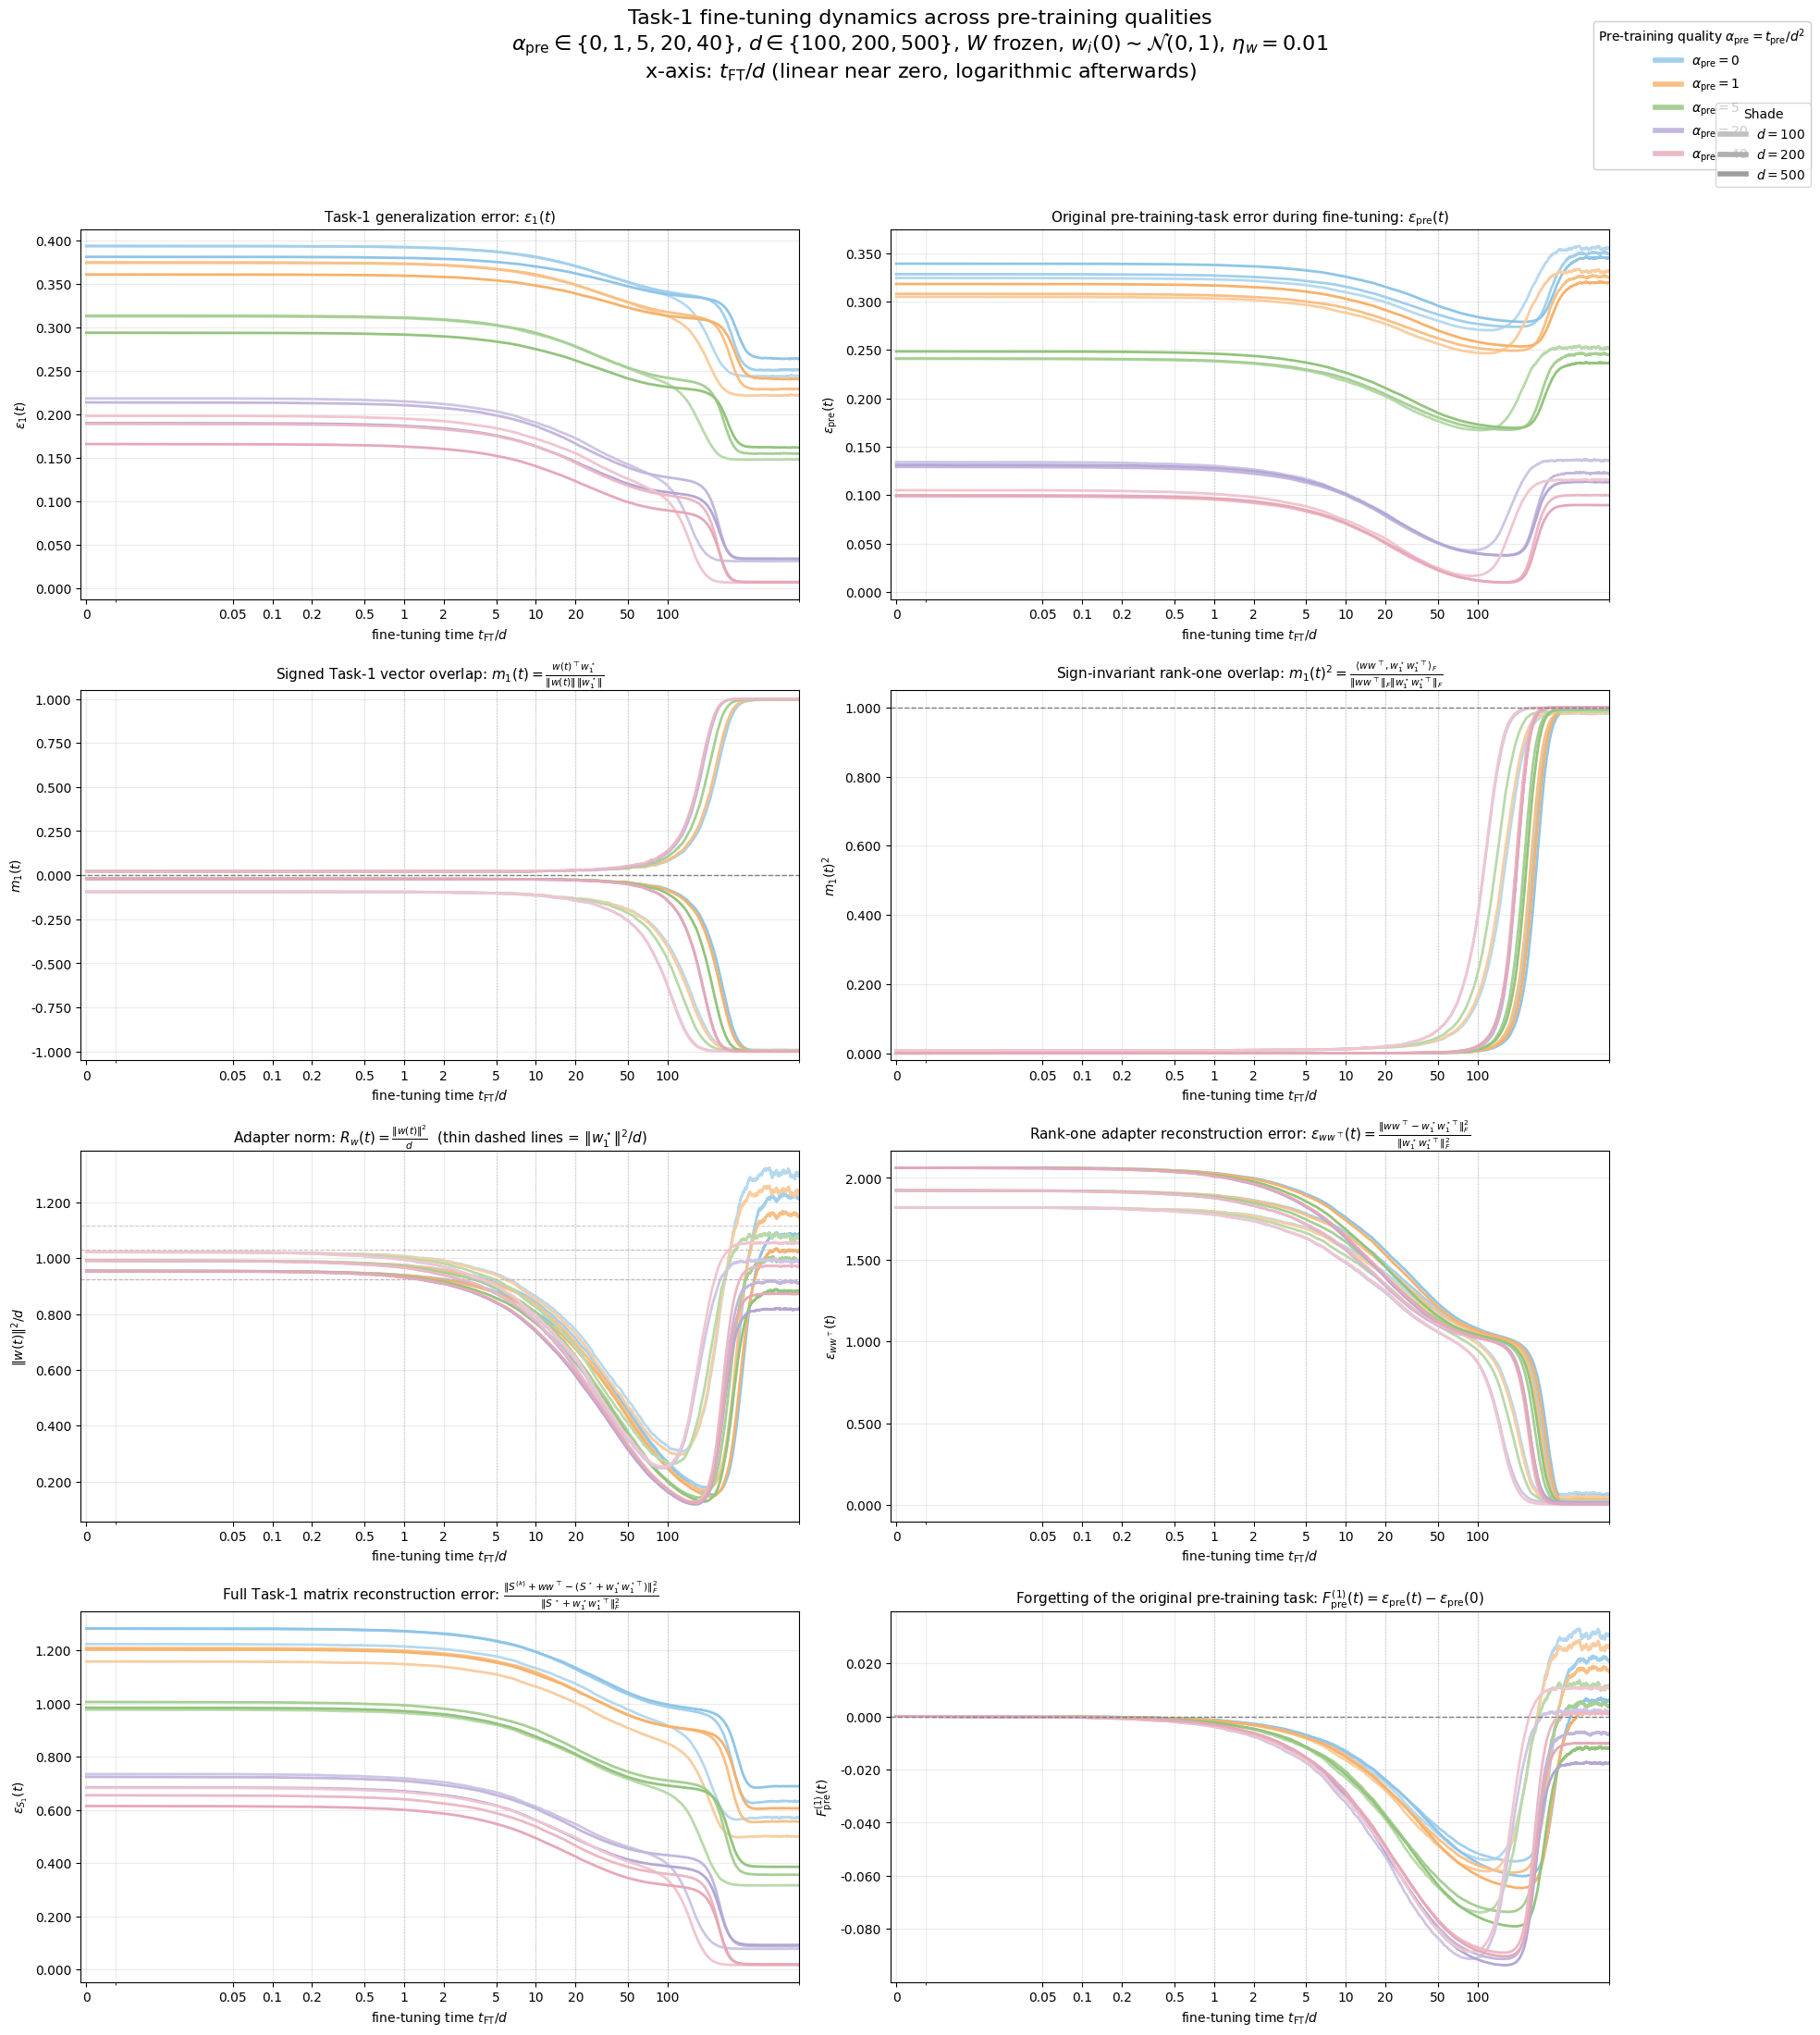

In [2]:
# ============================================================
# TASK-1 FINE-TUNING DYNAMICS
#
# Compare:
#   alpha_pre = t_pre / d^2 in {0, 1, 5, 20, 40}
#   d in {100, 200, 500}
#
# Color encoding:
#   - one pastel color family per alpha_pre
#   - three shades within each family for d=100,200,500
#
# x-axis = t_FT / d
# fine-tuning horizon = 100 d
#
# ============================================================




# ============================================================
# Configuration
# ============================================================

D_VALUES = [100, 200, 500]

ALPHAS = [0, 1, 5, 20, 40]

T = 5

LR = 0.01
INIT_SCALE = 1.0

W_INIT_SEED = 21
SGD_SEED = 22

MAX_T_OVER_D = 1000.0

FIGSIZE = (20, 22)
LINEWIDTH = 2.0


# ============================================================
# Pastel alpha colors
# ============================================================

# One clearly distinguishable pastel family per alpha.
ALPHA_BASE_COLORS = {
    0:  "#8EC5E8",   # pastel blue
    1:  "#F6B26B",   # pastel orange
    5:  "#93C47D",   # pastel green
    20: "#B4A7D6",   # pastel purple
    40: "#E6A8B7",   # pastel rose
}


# Shade strength within a color family.
#
# d=100 -> lighter
# d=200 -> middle
# d=500 -> darker
D_SHADE_FACTOR = {
    100: 0.65,
    200: 0.82,
    500: 1.00,
}


def shade_color(hex_color, factor):
    """
    Generate shades of the same pastel base color.

    factor < 1 blends toward white.
    factor = 1 gives the original base color.
    """

    rgb = np.array(
        mcolors.to_rgb(hex_color)
    )

    white = np.ones(3)

    return tuple(
        white + factor * (rgb - white)
    )


COLOR_MAP = {
    (alpha, d): shade_color(
        ALPHA_BASE_COLORS[alpha],
        D_SHADE_FACTOR[d],
    )
    for alpha in ALPHAS
    for d in D_VALUES
}


# ============================================================
# Locate repository
# ============================================================

cwd = Path.cwd()

if (cwd / "results").exists():

    REPO_ROOT = cwd

elif (cwd.parent / "results").exists():

    REPO_ROOT = cwd.parent

else:

    REPO_ROOT = (
        cwd.parent
        if cwd.name == "notebooks"
        else cwd
    )


RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "quality_pretraining"
)


# ============================================================
# Formatting helpers
# ============================================================

def float_tag(value: float) -> str:

    return (
        f"{value:g}"
        .replace(".", "p")
        .replace("-", "m")
    )


def readable_decimal_formatter(x, pos):
    """
    Avoid scientific notation while retaining enough precision
    for small errors.
    """

    if x == 0:
        return "0.000"

    ax = abs(x)

    if ax >= 1e-3:
        return f"{x:.3f}"

    if ax >= 1e-4:
        return f"{x:.4f}"

    if ax >= 1e-5:
        return f"{x:.5f}"

    return f"{x:.6f}"


def configure_x_axis(ax):

    # Linear extremely close to zero, logarithmic afterwards.
    ax.set_xscale(
        "symlog",
        linthresh=0.05,
        linscale=1.0,
        base=10,
    )

    ax.set_xlim(
        -0.002,
        MAX_T_OVER_D,
    )

    ticks = [
        0,
        0.05,
        0.1,
        0.2,
        0.5,
        1,
        2,
        5,
        10,
        20,
        50,
        100,
    ]

    ticks = [
        t
        for t in ticks
        if t <= MAX_T_OVER_D
    ]

    labels = [
        "0",
        "0.05",
        "0.1",
        "0.2",
        "0.5",
        "1",
        "2",
        "5",
        "10",
        "20",
        "50",
        "100",
    ][:len(ticks)]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    ax.set_xlabel(
        r"fine-tuning time $t_{\mathrm{FT}}/d$"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.25,
    )


def style_axis(
    ax,
    ylabel,
    title,
    ylim=None,
):

    configure_x_axis(ax)

    formatter = FuncFormatter(
        readable_decimal_formatter
    )

    ax.yaxis.set_major_formatter(
        formatter
    )

    ax.yaxis.set_minor_formatter(
        formatter
    )

    ax.yaxis.offsetText.set_visible(
        False
    )

    ax.set_ylabel(
        ylabel
    )

    ax.set_title(
        title,
        fontsize=11,
    )

    if ylim is not None:

        ax.set_ylim(
            *ylim
        )


# ============================================================
# Construct all expected runs
# ============================================================

RUNS = {}

for alpha in ALPHAS:

    for d in D_VALUES:

        pretrain_step = int(
            alpha * d**2
        )

        label = (
            rf"$\alpha={alpha}$, $d={d}$"
        )

        RUNS[(alpha, d)] = {
            "label": label,
            "alpha": alpha,
            "d": d,
            "pretrain_step": pretrain_step,
        }


# ============================================================
# Load all available runs
# ============================================================

runs = {}

warnings_list = []


for key, info in RUNS.items():

    alpha = info["alpha"]
    d = info["d"]

    pretrain_step = (
        info["pretrain_step"]
    )

    base_dir = (
        RESULTS_ROOT
        / f"finetunetask1_d{d}_T{T}"
    )

    run_name = (
        f"prestep_{pretrain_step}"
        f"_lr{float_tag(LR)}"
        f"_init{float_tag(INIT_SCALE)}"
        f"_wseed{W_INIT_SEED}"
        f"_sgdseed{SGD_SEED}"
    )

    run_dir = (
        base_dir
        / run_name
    )

    metrics_path = (
        run_dir
        / "metrics.csv"
    )

    if not metrics_path.exists():

        warnings_list.append(
            f"alpha={alpha}, d={d}: "
            f"metrics not found yet"
        )

        continue


    df = pd.read_csv(
        metrics_path
    )

    df = (
        df
        .sort_values(
            "finetune_step"
        )
        .drop_duplicates(
            subset="finetune_step",
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )


    # Explicitly recompute t_FT / d.
    df["t_over_d"] = (
        df["finetune_step"] / d
    )


    if (df["finetune_step"] == 0).any():
        eps_pre_before_task1 = (
            df.loc[
                df["finetune_step"] == 0,
                "pretraining_error",
            ]
            .iloc[0]
        )
    else:
        # Fallback if step 0 is ever absent
        eps_pre_before_task1 = (
            df.iloc[0]["pretraining_error"]
        )

    df["pretraining_forgetting_task1"] = (
        df["pretraining_error"]
        - eps_pre_before_task1
    )


    runs[key] = {
        **info,
        "df": df,
        "run_dir": run_dir,
    }


# ============================================================
# Status
# ============================================================

if warnings_list:

    print(
        "Runs not available yet:"
    )

    for warning in warnings_list:
        print(
            "  -",
            warning
        )

    print()


if not runs:

    raise RuntimeError(
        "No fine-tuning runs could be loaded."
    )


print(
    f"Loaded {len(runs)} / "
    f"{len(ALPHAS) * len(D_VALUES)} runs."
)

print()


for (alpha, d), payload in sorted(
    runs.items()
):

    df = payload["df"]
    last = df.iloc[-1]

    print(
        f"alpha={alpha:>2}, "
        f"d={d:>3} | "
        f"step={int(last['finetune_step']):>7,d} | "
        f"t/d={last['t_over_d']:7.3f} | "
        f"task1={last['task1_error']:.6e} | "
        f"m1²={last['squared_overlap_w1']:.6f} | "
        f"||w||²/d={last['w_norm_sq_over_d']:.6f} | "
        f"eps_adapter="
        f"{last['adapter_reconstruction_error']:.6e} | "
        f"Fpre1="
        f"{last['pretraining_forgetting_task1']:.6e}"
    )


# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(
    4,
    2,
    figsize=FIGSIZE,
)

axes = axes.ravel()

# ============================================================
# Plot every run
# ============================================================

for (alpha, d), payload in sorted(
    runs.items()
):

    df = payload["df"]

    x = df["t_over_d"]

    color = COLOR_MAP[
        (alpha, d)
    ]


    # --------------------------------------------------------
    # 1. Task-1 generalization error
    # --------------------------------------------------------

    axes[0].plot(
        x,
        df["task1_error"],
        color=color,
        lw=LINEWIDTH,
    )


    # --------------------------------------------------------
    # 2. Original pretraining task error
    # --------------------------------------------------------

    axes[1].plot(
        x,
        df["pretraining_error"],
        color=color,
        lw=LINEWIDTH,
    )


    # --------------------------------------------------------
    # 3. Signed vector overlap
    #
    # m1 = w^T w1* / (||w|| ||w1*||)
    # --------------------------------------------------------

    axes[2].plot(
        x,
        df["signed_overlap_w1"],
        color=color,
        lw=LINEWIDTH,
    )


    # --------------------------------------------------------
    # 4. Sign-invariant rank-one overlap
    #
    # m1^2
    # --------------------------------------------------------

    axes[3].plot(
        x,
        df["squared_overlap_w1"],
        color=color,
        lw=LINEWIDTH,
    )


    # --------------------------------------------------------
    # 5. Adapter norm
    #
    # ||w||^2 / d
    # --------------------------------------------------------

    axes[4].plot(
        x,
        df["w_norm_sq_over_d"],
        color=color,
        lw=LINEWIDTH,
    )


    # Teacher adapter norm for this realization.
    teacher_norm = (
        df[
            "w1_star_norm_sq_over_d"
        ]
        .iloc[0]
    )

    axes[4].axhline(
        teacher_norm,
        color=color,
        linestyle="--",
        linewidth=0.8,
        alpha=0.40,
    )


    # --------------------------------------------------------
    # 6. Rank-one adapter reconstruction error
    # --------------------------------------------------------

    axes[5].plot(
        x,
        df[
            "adapter_reconstruction_error"
        ],
        color=color,
        lw=LINEWIDTH,
    )


    # --------------------------------------------------------
    # 7. Full Task-1 matrix reconstruction error
    # --------------------------------------------------------

    axes[6].plot(
        x,
        df[
            "task1_matrix_error"
        ],
        color=color,
        lw=LINEWIDTH,
    )

    # --------------------------------------------------------
    # 8. Forgetting of the original pre-training task
    #
    # F_pre^(1)(t)
    #     = eps_pre(t) - eps_pre(0)
    # --------------------------------------------------------

    axes[7].plot(
        x,
        df["pretraining_forgetting_task1"],
        color=color,
        lw=LINEWIDTH,
    )



# ============================================================
# Vertical reference lines
# ============================================================

for ax in axes:

    for reference_t in [
        1,
        5,
        10,
        20,
        50,
        100,
    ]:

        ax.axvline(
            reference_t,
            color="lightgray",
            linestyle=":",
            linewidth=0.9,
            zorder=0,
        )


# ============================================================
# Horizontal reference lines
# ============================================================

# Signed overlap zero
axes[2].axhline(
    0.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
)


# Perfect rank-one orientation
axes[3].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
)


# No forgetting of the original pre-training task
axes[7].axhline(
    0.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
)


# ============================================================
# Titles
# ============================================================

style_axis(
    axes[0],

    ylabel=r"$\epsilon_1(t)$",

    title=(
        r"Task-1 generalization error: "
        r"$\epsilon_1(t)$"
    ),
)


style_axis(
    axes[1],

    ylabel=(
        r"$\epsilon_{\mathrm{pre}}(t)$"
    ),

    title=(
        r"Original pre-training-task error during fine-tuning: "
        r"$\epsilon_{\mathrm{pre}}(t)$"
    ),
)


style_axis(
    axes[2],

    ylabel=r"$m_1(t)$",

    title=(
        r"Signed Task-1 vector overlap: "
        r"$m_1(t)="
        r"\frac{w(t)^\top w_1^\star}"
        r"{\|w(t)\|\,\|w_1^\star\|}$"
    ),

    ylim=(-1.05, 1.05),
)


style_axis(
    axes[3],

    ylabel=r"$m_1(t)^2$",

    title=(
        r"Sign-invariant rank-one overlap: "
        r"$m_1(t)^2="
        r"\frac{\langle ww^\top,"
        r"w_1^\star w_1^{\star\top}\rangle_F}"
        r"{\|ww^\top\|_F"
        r"\|w_1^\star w_1^{\star\top}\|_F}$"
    ),

    ylim=(-0.02, 1.05),
)


style_axis(
    axes[4],

    ylabel=(
        r"$\|w(t)\|^2/d$"
    ),

    title=(
        r"Adapter norm: "
        r"$R_w(t)=\frac{\|w(t)\|^2}{d}$"
        r"  (thin dashed lines = "
        r"$\|w_1^\star\|^2/d$)"
    ),
)


style_axis(
    axes[5],

    ylabel=(
        r"$\epsilon_{ww^\top}(t)$"
    ),

    title=(
        r"Rank-one adapter reconstruction error: "
        r"$\epsilon_{ww^\top}(t)="
        r"\frac{\|ww^\top-"
        r"w_1^\star w_1^{\star\top}\|_F^2}"
        r"{\|w_1^\star w_1^{\star\top}\|_F^2}$"
    ),
)


style_axis(
    axes[6],

    ylabel=(
        r"$\epsilon_{S_1}(t)$"
    ),

    title=(
        r"Full Task-1 matrix reconstruction error: "
        r"$\frac{\|S^{(k)}+ww^\top-"
        r"(S^\star+w_1^\star w_1^{\star\top})\|_F^2}"
        r"{\|S^\star+w_1^\star w_1^{\star\top}\|_F^2}$"
    ),
)

style_axis(
    axes[7],

    ylabel=(
        r"$F_{\mathrm{pre}}^{(1)}(t)$"
    ),

    title=(
        r"Forgetting of the original pre-training task: "
        r"$F_{\mathrm{pre}}^{(1)}(t)="
        r"\epsilon_{\mathrm{pre}}(t)"
        r"-\epsilon_{\mathrm{pre}}(0)$"
    ),
)




# ============================================================
# Legends
# ============================================================

# ------------------------------------------------------------
# Alpha legend:
# one representative medium shade per alpha
# ------------------------------------------------------------

alpha_handles = [

    Line2D(
        [0],
        [0],

        color=COLOR_MAP[
            (alpha, 200)
        ],

        lw=4,

        label=(
            rf"$\alpha_{{\mathrm{{pre}}}}={alpha}$"
        ),
    )

    for alpha in ALPHAS
]


# ------------------------------------------------------------
# Dimension legend:
# use one neutral color with increasing darkness
# ------------------------------------------------------------

neutral_base = "#9E9E9E"

d_handles = [

    Line2D(
        [0],
        [0],

        color=shade_color(
            neutral_base,
            D_SHADE_FACTOR[d],
        ),

        lw=4,

        label=rf"$d={d}$",
    )

    for d in D_VALUES
]


# Alpha legend
legend_alpha = fig.legend(

    handles=alpha_handles,

    title=(
        r"Pre-training quality "
        r"$\alpha_{\mathrm{pre}}=t_{\mathrm{pre}}/d^2$"
    ),

    loc="upper right",

    bbox_to_anchor=(
        0.985,
        0.995,
    ),

    ncol=1,

    frameon=True,
)


# Keep first legend when adding second one
fig.add_artist(
    legend_alpha
)


# Dimension shade legend
fig.legend(

    handles=d_handles,

    title="Shade",

    loc="upper right",

    bbox_to_anchor=(
        0.985,
        0.955,
    ),

    ncol=1,

    frameon=True,
)


# ============================================================
# Global title
# ============================================================

fig.suptitle(

    "Task-1 fine-tuning dynamics across pre-training qualities\n"

    r"$\alpha_{\mathrm{pre}}\in\{0,1,5,20,40\}$, "
    r"$d\in\{100,200,500\}$, "

    r"$W$ frozen, "
    r"$w_i(0)\sim \mathcal{N}(0,1)$, "
    r"$\eta_w=0.01$"

    "\n"

    r"x-axis: $t_{\mathrm{FT}}/d$ "
    r"(linear near zero, logarithmic afterwards)",

    fontsize=16,

    y=0.998,
)


plt.tight_layout(
    rect=[
        0,
        0,
        0.88,
        0.95,
    ]
)

plt.show()